In [1]:
#실시간성으로 빨리 문제 파악하는 것이 중요하기 때문에, 우너인 빨리 찾아서 빨리 조치하는 게 생산의 loss줄일 수 있음.

# 설비예지보전 모델 개발  / PHM 모델 개발

In [13]:
# ==============================================================================
# 멀티변량 시계열 기반 설비 고장 조기 예측 + 품질 원인 분류 멀티태스크 모델

# 목표:
# 1. 제조 설비 센서 데이터를 시뮬레이선
# 2. 시계열 윈도우를 생성
# 3. 1D CNN + BiLSTM = Attention 기반 멀티태스크 모델 학습
# 4. 고장 여부 ( 이진 분류 ) 와 원인 분류 (멀티클래스) 를 동시에 수행
# 5. 모델, 스케일러, 학습 이력, 예측 결과를 저장
# 6. 저장된 모델을 다시 읽어와 신규 데이터 예측을 수행
# 7. 학습 결과와 예측 결과를 시각화
# ==============================================================================

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.src.layers import GlobalAveragePooling1D
from sklearn.externals.array_api_compat.dask.array import astype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,auc

import joblib
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, MaxPooling1D, Input, Conv1D, MaxPool1D
from tensorflow.keras.layers import Bidirectional, LSTM, GlobalMaxPool1D
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Add
from tensorflow.keras.layers import Concatenate

from tensorflow.keras.models import Model

# 학습 제어 콜백을 불러온다.
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau, ModelCheckpoint
np.random.seed(42)
tf.random.set_seed(42)

- 실시간 멀티테스크와 앙상블 모델
- 하드웨어에서 발생하는 진동 /소음으로 고장 여부 진단. -> 진단할 때도 binary classification 이 아니라 multi-classification 이 되어야 함.
- 원격의료진단 응급실이나 병실에 환자들 호흡기 / 맥박측정기 끼고 있는 환자들 상태를 실시간으로 측정 못하니까 측정 장비 데이터 가지고 환자 이상여부 실시간 탐지, 병명
- 원격진단 / 제어
- 임상실험 데이터 공유해주는 사이트가 있다?!!?!
- 최상 임상 실험 할 수 있는 시뮬레이션 결과를 의료 레시피

# 음향정보는 2초면 특징이 다 나오기 때문에, 음향분석을 할 때, 2초씩만 있으면 충분하다. 특징이 다나옴.

In [15]:
# ======================================
# 1 데이터 설정
# ======================================

# 전체 시뮬레이션 샘플 수를 정의
n_sequences = 4000

# 한 시퀀스의 길이를 정의
seq_len = 60

# 센서 개수를 저의
n_features = 6

# 품질 원인 클래스 수를 정의
n_cause_classes = 4

# 센서 이름을 정의
# current = 전류
feature_names = ["temperature","pressure","vibration","current","speed",'thickness']

In [16]:
# ======================================
# 2. 시계열 데이터 생성
# ======================================

# 하나의 시퀀스를 생성하는 함수를 저의

def generate_sequence(seq_len, mode, cause_class):
    # 시간축을 0부터 1까지 균등 분할하여 생성
    t = np.linspace(0,1, seq_len)

    #temp 기본 패턴을 생성
    temperature = 50+3 *np.sin(2*np.pi* 2 * t) + np.random.normal(0,0.6, seq_len)

    # pressure 기본 패턴을 생성
    pressure = 100+5 *np.cos(2*np.pi* 1.5 * t) + np.random.normal(0,0.8, seq_len)


    # vibration 기본 패턴을 생성
    vibration = 10+0.5 *np.sin(2*np.pi* 6 * t) + np.random.normal(0,0.3, seq_len)


    # current 기본 패턴을 생성
    current = 20 +1.2 *np.sin(2*np.pi* 3 * t) + np.random.normal(0,0.4, seq_len)


    # speed 기본 패턴을 생성
    speed = 1500+ 25 *np.cos(2*np.pi* 2.5 * t) + np.random.normal(0,5, seq_len)

    # thickness 기본 패턴을 생성
    thickness = 1.20+ 0.02 *np.sin(2*np.pi* 1.2 * t) + np.random.normal(0, 0.01, seq_len)

    # 정상 모드가 아니라면 이상 패턴을 삽입
    if mode == 'fault':
        # 원인 클래스가 0이면 온도와 전류 상승 패턴을 삽입
        if cause_class == 0 :
            temperature += np.linspace(0,10,seq_len)
            current += np.linspace(0,8,seq_len)

        # 원인 클래스가 1이면 압력 급상승과 두께 편차를 삽입
        elif cause_class == 1 :
            pressure += np.linspace(0,18,seq_len)
            thickness += np.linspace(0, 0.10,seq_len)

        # 원인 클래스가 2이면 진동 증가와 속도 저하를 삽입
        elif cause_class == 2 :
            vibration += np.linspace(0,6,seq_len)
            speed -= np.linspace(0,160 ,seq_len)

        # 원인 클래스 3이면 복합 이상 패턴을 삽입
        elif cause_class == 3 :
            temperature += np.linspace(0,6,seq_len)
            pressure += np.linspace(0,10, seq_len)
            vibration += np.linspace(0,3,seq_len)
            current += np.linspace(0,4,seq_len)

    # 생성된 각 센서를 열 방향으로 쌓아 하나의 2차원 시퀀스로 만듬
    sequence = np.column_stack([temperature,pressure,vibration,current,speed,thickness])

    # 생성된 시퀀스를 반환
    return sequence

In [17]:
# ======================================
# 3. 전체 데이터셋 생성
# ======================================

# 입력 시퀀스를 저장할 리스트를 생서
X_list = []

# 고장 여부 라벨을 저장할 리스트를 생성
y_fault_list =[]

# 원인 클래스 라벨을 저장할 리스트를 생성
y_cause_list = []

# 전체 샘플 수 만큼 반복
for i in range(n_sequences):
    mode = np.random.choice(["normal",'fault'], p = [0.7,0.3])
    # 70%는 정상, 나머진느 이상이 되도록 랜덤하게 모드 선택

    if mode == 'normal':
         cause_class = 0

     # 이상일 경우 1~3 중 하나를 원인 클래스로 사용
    else :
        cause_class = np.random.choice([1,2,3])

    # 시퀀스를 생성
    seq = generate_sequence(seq_len, mode, cause_class)

    # 입력 리스트에 시퀀스를 추가
    X_list.append(seq)

    # 고장 여부 라벨을 추가, 정상은 0, 이상은 1
    y_fault_list.append(0 if mode == 'normal'else 1)

    # 원인 클래스 라벨을 추가
    y_cause_list.append(cause_class)

# 입력 리스트를 numpy 배열로 변환
X = np.array(X_list)

# 고장 여부 라벨을 numpy 배열로 변환
y_fault = np.array(y_fault_list)

# 원인 클래스 라벨을 numpy 배열로 변환
y_cause = np.array(y_cause_list)


# 고장 여부 라벨 shape를 출력
print("y_fault shape:", y_fault.shape)
# 원인 라벨 shape를 출력
print("y_cause shape:", y_cause.shape)
# 고장 여부 클래스 분포를 출력
print("Fault label distribution : =\n ", pd.Series(y_fault).value_counts().sort_index())
# 원인 클래스 분포를 출력
print("Cause label distribution : =\n ", pd.Series(y_cause).value_counts().sort_index())

y_fault shape: (4000,)
y_cause shape: (4000,)
Fault label distribution : =
  0    2800
1    1200
Name: count, dtype: int64
Cause label distribution : =
  0    2800
1     395
2     387
3     418
Name: count, dtype: int64


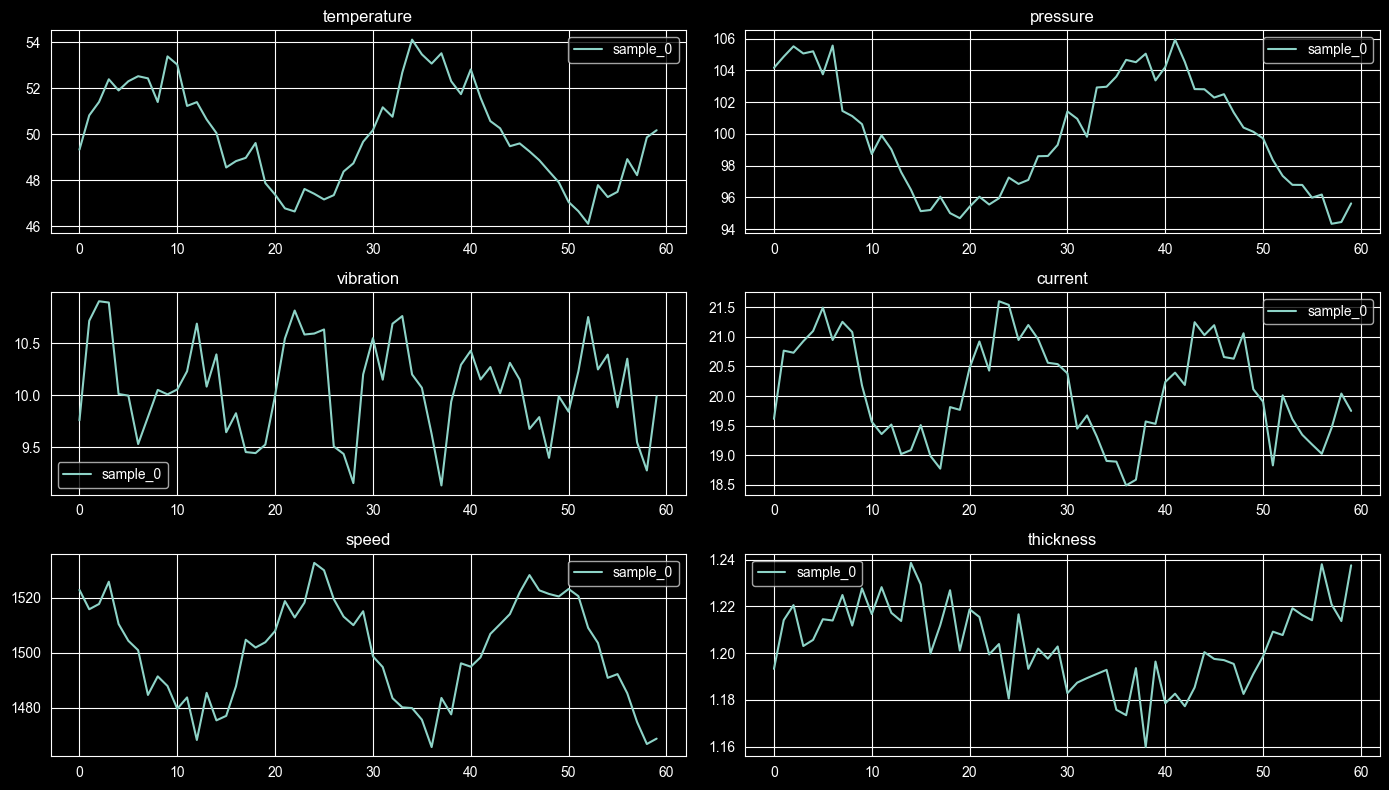

In [18]:
# ======================================
# 4. 시퀀스 데이터 시각화
# ======================================

plt.figure(figsize=(14,8))

# 각 센서별로 subplot을 생성하기 위해 반복
for idx in range(n_features):
    # 3행 2열 구조와 SUBPLOT 을 생성
    plt.subplot(3,2, idx+1)

    # 첫 번째 정상 샘플의 해당센서 시퀀스를 푯
    plt.plot(X[0, :, idx], label = "sample_0")
    plt.title(feature_names[idx])
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
# ======================================
# 5. 학습 / 검증 /테스트 데이터 분리
# ======================================

# 핛브용과 임시용으로 데이터를 분리
X_train,X_temp, y_fault_train, y_fault_temp, y_cause_train, y_cause_temp = train_test_split(
    X, y_fault,y_cause, test_size=0.2, random_state=42, stratify=y_fault
)

# 임시 데이터를 검증용과 테스트용으로 분리
X_val,X_test, y_fault_val, y_fault_test, y_cause_val, y_cause_test = train_test_split(
    X_temp, y_fault_temp,y_cause_temp, test_size=0.5, random_state=42, stratify=y_fault_temp
)

# 분리 결과 shape 를 출력
print("Train : ", X_train.shape, y_fault_train.shape, y_cause_train.shape)
print("Val : ", X_val.shape, y_fault_val.shape, y_cause_val.shape)
print("Test : ", X_test.shape, y_fault_test.shape, y_cause_test.shape)


Train :  (3200, 60, 6) (3200,) (3200,)
Val :  (400, 60, 6) (400,) (400,)
Test :  (400, 60, 6) (400,) (400,)


In [22]:
# ======================================
# 6. 시계열 데이터 정규화
# ======================================

# 시계열 데이터 : (samples, timestamps, feature) 이런 식으로 3차원으로 이루어져 있음
# 스케일러는 2D 밖에 적용이 안 됨.
# 시계열 데이터는 3차원 형태이므로 스케일러 적용을 위해 2차원으로 펼쳐야 함.
# 먼저 StandardScaler 객체를 생성
scaler = StandardScaler()

# 학습 데이터를 (샘플 * 시점, 센서 수 ) 형태로 reshape
X_train_2d = X_train.reshape(-1, n_features)

# 검증 데이터를 2차원으로 reshape
X_val_2d = X_val.reshape(-1, n_features)

# 테스트 데이터를 2차원으로 reshape
X_test_2d = X_test.reshape(-1, n_features)

# 학습 데이터 기준으로 스케일러를 학습하고 변환
X_train_scaled_2d = scaler.fit_transform(X_train_2d)

# 검증 데이터를 동일 스케일러로 변환
X_val_scaled_2d = scaler.transform(X_val_2d)

# 테스트 데이터를 동일 스케일러로 변환
X_test_scaled_2d = scaler.transform(X_test_2d)

# 다시 원래의 3차원 시계열 형태로 복원
X_train_scaled = X_train_scaled_2d.reshape(-1, seq_len, n_features)

# 검증 데이터도 3차원으로 복원
X_val_scaled = X_val_scaled_2d.reshape(-1, seq_len, n_features)

# 테스트 데이터도 3차원으로 복원
X_test_scaled = X_test_scaled_2d.reshape(-1, seq_len, n_features)

In [24]:
# ======================================
# 7. 고급 멀티태스크 모델 구성
#   구조 :
#   입력 -> Conv1D -> Pooling -> BiLSTM -> Self-Attention -> Dense
#       -> 출력 1 : fault_output(이진 분류)
#       -> 출력 2 : cause_output(멀티클래스 분류)
# ======================================

# Conv1D = 시계열 데이터 특징 뽑기
# Pooling = 스트라이드 하면서 세부 특징 뽑기
# BiLSTM = 시간상의 연결 & 해석 시간 의존성 학습
# Self-Attention = 데이터의 관계패턴 / 중요도 파악
# Dense = 분류 출력
# fault_output : 양불 판단
# cause_output : 원인 판단


# 입력 텐서 레이어 정의
inputs = Input(shape = (seq_len, n_features), name = "sensor_input")

# 첫 번째 1D CNN 레이어를 적용해서 기본적인 패턴 추출
x = Conv1D(filters= 64, kernel_size=3, padding="same", activation='relu',name='conv1')(inputs)
x = Dropout(0.2, name = 'dropout_conv1')(x) # 과적합 방지를 위해 드롭아웃 적용 (20%)

# 두 번째 1D CNN 레이어를 적용해서 조금 더 복잡한 패턴 추출
x = Conv1D(filters= 64, kernel_size=3, padding="same", activation='relu',name='conv2')(x)
x = Dropout(0.2, name = 'dropout_conv2')(x) # 과적합 방지를 위해 드롭아웃 적용 (20%)

# 특징을 뽑아 핵심만 남기는 압축 , pooling
# 풀링을 적용해서 시퀀스 길이를 축소하고 핵심 특징만 남김
x = MaxPool1D(pool_size= 2, name = 'maxpool1')(x)

# 시간 의존성 파악하기 위해서 LSTM 레이어 구성
# 양 방향 LSTM을 적용해서 과거와 현재 미래의 연결성을 반영
x = Bidirectional(LSTM(64, return_sequences=True), name = "bilstm")(x)

# self-Attention 적용 (이거 하려면 정규화 해줘야 함)
# Self-Attention 적용 전 정규화 수행
attn_input = LayerNormalization(name = 'attn_norm1')(x)

# 멀티헤드 어텐션을 적용해서 중요한 시점 간 관계를 학습
'''
MultiHeadAttention : 여러 개의 Attention을 동시에 적용해서 다양한 관점의 관계를 학습.
기본적인 attention 모델 적용한 게 아니라 멀티 어텐션 적용
기본 attention 무ㅗ델은 하나의 관계만 보기 때문에 다양한 패턴 보는 데 한계가 있음
멀티 는 한 번에 하나의 관계만 보는 게 아니라, 복잡한 패턴의 관계를 다각도에서 다방면에서 동시에 병렬로 볼 수 있음.
어떤 시점의 중요한 패턴을 학습할 수 있음
--> 동시 attention 병렬 처리 (속도 향상)
--> 다양한 패턴 학습 ( 표현력 향상)
'''
attn_output = MultiHeadAttention(
    num_heads = 4,
    key_dim = 32,
    name = 'multihead_attention'
)(attn_input, attn_input)


# 실제값 vs 예측값 잔차 // 잔차 연결을 통해 원본 특징과 어텐션 결과 더해줌
x = Add(name = "attn_residual")([x, attn_output])

# 다시 정규화 수행
x = LayerNormalization(name = "attn_norm2")(x)

# 시계열 전체 정보를 요약하기 위한 GlobalAveragePooling1D 적용
x = GlobalAveragePooling1D(name = "global_avg_pool")(x)


# --- 여기서부터 출력층 레이어 구성하는 것.
# 공통 표현 학습용 Dense 레이어 추가
# 기본 딥러닝 구조로 돌아온 것.
shared = Dense(128, activation = "relu", name= "shared_dense1")(x)
shared = Dropout(0.3, name= "shared_dropout1")(shared)

# Dense 레이어 다시 추가
shared = Dense(64, activation='relu', name= "shared_dense2")(shared)
shared = Dropout(0.2, name = 'shared_dropout2')(shared)

# 고장 여부를 예측하기 위한 Dense Layer . 출력을 위한 분류기 만드는 것
fault_branch = Dense(32, activation='relu',name = 'fault_dense')(shared)

# 고장 여부 이진분류를 위한 출력층
fault_output = Dense(1, activation='sigmoid', name= "fault_output")(fault_branch)


# 멀티클래스에에 대한 분류기 레이어
# 원인 분류용 분류기 Dense 레이어 정의
cause_branch = Dense(32, activation='relu',name = 'cause_dense')(shared)

# 원인 멀티클래스 분류 출력층 저의
cause_output = Dense(n_cause_classes, activation='softmax', name = 'cause_output')(cause_branch)

# 멀티출력 모델 생성
model = Model(inputs = inputs , outputs = [fault_output, cause_output], name = 'predictive_maintenance_multitask_model')

# 모델 요약을 출력
model.summary()

Model: "predictive_maintenance_multitask_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 60, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 60, 64)    │      1,216 │ sensor_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_conv1       │ (None, 60, 64)    │          0 │ conv1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 60, 64)    │     12,352 │ dropout_conv1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_conv2       │ (None, 60, 64)    │          0 │ conv2[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 30, 64)    │          0 │ dropout_conv2[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 30, 128)   │     66,048 │ maxpool1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm1          │ (None, 30, 128)   │        256 │ bilstm[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multihead_attention │ (None, 30, 128)   │     66,048 │ attn_norm1[0][0], │
│ (MultiHeadAttentio… │                   │            │ attn_norm1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_residual (Add) │ (None, 30, 128)   │          0 │ bilstm[0][0],     │
│                     │                   │            │ multihead_attent… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_norm2          │ (None, 30, 128)   │        256 │ attn_residual[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 128)       │          0 │ attn_norm2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense1       │ (None, 128)       │     16,512 │ global_avg_pool[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout1     │ (None, 128)       │          0 │ shared_dense1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense2       │ (None, 64)        │      8,256 │ shared_dropout1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout2     │ (None, 64)        │          0 │ shared_dense2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fault_dense (Dense) │ (None, 32)        │      2,080 │ shared_dropout2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cause_dense (Dense) │ (None, 32)        │      2,080 │ shared_dropout2[

 Total params: 175,269 (684.64 KB)

 Trainable params: 175,269 (684.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 데이터와 피쳐가 많을수록 모델 구성을 깊이있게 했을 때 학습이 잘 된다.

In [25]:
# ======================================
# 8. 모델 컴파일
# 모델 학습 목표 : acc 올리고 loss 줄이는 것.
# loss, acc는 어떤 지표로 정릐할지
# ======================================

# 멀티테스크 손실함수와 평가지표를 지정하여 모델을 컴파일.
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = {
        "fault_output": "binary_crossentropy",
        "cause_output" : "sparse_categorical_crossentropy",
    },
    loss_weights={
        "fault_output": 1.0,
        "cause_output": 1.0
    },
    metrics={
        "fault_output": ["accuracy"],
        "cause_output": ["accuracy"]
    }
)

# learning_rate 너무 크면 봐야할 곳 못 보고, 학습안되고, 위로 튀게 됨.
# learning_rate 작으면 기울기 타고 안 내려옴 ㅋㅋ local minimum 에 빠짐

In [26]:
# ======================================
# 9. 콜백 설정 (조기종료 설정)
# ======================================

# 검증 손실이 개선되지 않으면 학습을 조기 종료하는 콜백
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# 검증 손실이 정체되어있으면 학습을 조기 종료하는 콜백
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5 ,
    patience=5,
    min_lr= 1e-6
)

# 교차검증을 통해 가장 좋은 모델을 파일로 저장하는 콜백

checkpoint = ModelCheckpoint(
    filepath="../data/best_multitask_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

In [27]:
# ======================================
# 10. 모델 학습
# ======================================

# 모델을 학습하고 학습 이력을 history 객체에 저장

history = model.fit(
    X_train_scaled,
    {
        "fault_output": y_fault_train,
        "cause_output": y_cause_train
    },
    validation_data= (
        X_val_scaled,
        {
            "fault_output": y_fault_val,
            "cause_output": y_cause_val
        }
    ),
    epochs = 50,
    batch_size = 64,
    callbacks = [early_stop,reduce_lr, checkpoint],
    verbose = 1
)

Epoch 1/50
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - cause_output_accuracy: 0.7675 - cause_output_loss: 0.5242 - fault_output_accuracy: 0.9227 - fault_output_loss: 0.2258 - loss: 0.7500
Epoch 1: val_loss improved from None to 0.00016, saving model to ../data/best_multitask_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - cause_output_accuracy: 0.9266 - cause_output_loss: 0.1924 - fault_output_accuracy: 0.9747 - fault_output_loss: 0.0839 - loss: 0.2763 - val_cause_output_accuracy: 1.0000 - val_cause_output_loss: 1.2595e-04 - val_fault_output_accuracy: 1.0000 - val_fault_output_loss: 5.1871e-05 - val_loss: 1.6269e-04 - learning_rate: 0.0010
Epoch 2/50
49/50 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - cause_output_accuracy: 0.9999 - cause_output_loss: 0.0016 - fault_output_accuracy: 1.0000 - fault_output_loss: 4.6769e-04 - loss: 0.0021
Epoch 2: val_loss improved from 0.00016 to 0.00002, saving model to ../data/best_multitask_model.keras
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - cause_output

In [28]:
# ======================================
# 11. 테스트 성능 평가
# ======================================
# 테스트 데이터에서 모델 성능을 평가
eval_result = model.evaluate(
    X_test_scaled,
    {
        "fault_output": y_fault_test,
        "cause_output": y_cause_test
    },
    verbose=0
)

# 평가 결과를 출력
print("Evaluation Result : ",eval_result)

Evaluation Result :  [3.459357245105821e-08, 1.8726939998714442e-08, 1.6047403406105332e-08, 1.0, 1.0]


In [33]:
# ======================================
# 12. 테스트 데이터 예측
# ======================================
# 테스트 데이터에 대한 예측 수행
fault_prob_test, cause_prob_test = model.predict(X_test_scaled)


# 이진 분류니까 0 또는 1 클래스로 변환
fault_pred_test = (fault_prob_test.flatten() >= 0.5 ).astype(int)

# 원인 클래스는 가장 큰 확률을 선택하는 argmax적용
cause_pred_test = np.argmax(cause_prob_test, axis =1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [34]:
# ======================================
# 13. 성능 출력 - 고장 여부
# ======================================

# 고장 여부 정확도 계산
fault_acc = accuracy_score(y_fault_test, fault_pred_test)

# Confusion Matrix 계산
fault_cm = confusion_matrix(y_fault_test, fault_pred_test)

#  고장 여부 정확도 출력
print("\n [고장 여부 이진분류 성능]")
print("Accuracy : ", fault_acc)

# 고장 여부 Confusion Matrix 출력
print("Confusion Matrix : \n", fault_cm)

# 고장 여부 분류 리포트 출력
print("Classification Report : \n", classification_report(y_fault_test, fault_pred_test))


 [고장 여부 이진분류 성능]
Accuracy :  1.0
Confusion Matrix : 
 [[280   0]
 [  0 120]]
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       280
           1       1.00      1.00      1.00       120

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [35]:
# ======================================
# 14. 성능 출력 - 원인 분류
# ======================================

# 원인 분류 정확도 계산
cause_acc = accuracy_score(y_cause_test, cause_pred_test)

# 원인 분류 Confusion Matrix 계산
cause_cm = confusion_matrix(y_cause_test, cause_pred_test)

#  원인 분류 정확도 출력
print("\n [원인 멀티클래스 분류 성능]")
print("Accuracy:", cause_acc)

# 원인 분류 Confusion Matrix 출력
print("Confusion Matrix:\n", cause_cm)

# 원인 분류 리포트 출력
print("Classification Report : \n", classification_report(y_cause_test, cause_pred_test))


 [원인 멀티클래스 분류 성능]
Accuracy: 1.0
Confusion Matrix:
 [[280   0   0   0]
 [  0  30   0   0]
 [  0   0  38   0]
 [  0   0   0  52]]
Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       280
           1       1.00      1.00      1.00        30
           2       1.00      1.00      1.00        38
           3       1.00      1.00      1.00        52

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [36]:
# ======================================
# 15. 모델 / 스케일러 /학습 이력 저장
# ======================================
# 전체 모델을 파일로 저장

model.save("final_multitask_model.keras")

# 스케일러를 파일로 저장
joblib.dump(scaler, "timeseries_scaler.pkl")

# 학습 이력을 데이터프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습 이력을 csv 파일로 저장
history_df.to_csv("training_history.csv", index=False)

# 저장 완료 메세지를 출력
print("모델, 스케일러, 학습 이력 저장 완료")


모델, 스케일러, 학습 이력 저장 완료


In [37]:
# ======================================
# 16. 저장된 모델 / 스케일러 불러오기
# ======================================

# 저장된 모델을 다시 불러오기
loaded_model = tf.keras.models.load_model("final_multitask_model.keras")

# 저장된 스케일러 다시 불러오기
loaded_scaler = joblib.load("timeseries_scaler.pkl")

# 저장된 학습 이력 다시 불러오기
loaded_history_df = pd.read_csv("training_history.csv")

# 불러온 학습 이력 일부를 출력
print(loaded_history_df.head())

# 저장 완료 메세지를 출력
print("모델, 스케일러, 학습 이력 저장 완료")


   cause_output_accuracy  cause_output_loss  fault_output_accuracy  \
0               0.926562           0.192385               0.974688   
1               0.999687           0.001627               1.000000   
2               1.000000           0.000458               1.000000   
3               1.000000           0.000346               1.000000   
4               1.000000           0.000227               1.000000   

   fault_output_loss      loss  val_cause_output_accuracy  \
0           0.083905  0.276290                        1.0   
1           0.000402  0.002029                        1.0   
2           0.000189  0.000647                        1.0   
3           0.000142  0.000488                        1.0   
4           0.000061  0.000289                        1.0   

   val_cause_output_loss  val_fault_output_accuracy  val_fault_output_loss  \
0               0.000126                        1.0           5.187097e-05   
1               0.000013                        1.0     

In [41]:
# ======================================
# 17. 신규 데이터 생성
# ======================================
# 정상 vs 이상 만들어서 사용
# 학습 데이터의 자리수,타입, 포멧, 스케일러
# 신규 샘플 시퀀스 데이터를 저장할 리스트 생성
new_sequences = []

# 첫 번째 신규 샘플은 정상 패턴으로 생성
new_sequences.append(generate_sequence(seq_len = seq_len, mode='normal', cause_class=0))

# 두 번째 신규 샘플은 원인 1 유형의 이상 패턴으로 생성
new_sequences.append(generate_sequence(seq_len = seq_len, mode='fault', cause_class=1))

# 세 번째 신규 샘플은 원인 2 유형의 이상 패턴으로 생성
new_sequences.append(generate_sequence(seq_len = seq_len, mode='fault', cause_class=2))

# 신규 샘플을 numpy 배열로 변환
new_sequences = np.array(new_sequences)

# 신규 데이터를 2차원으로 펼침( 시계열 데이터 3차원, 정규화는 2차원 필요
new_sequences_2d = new_sequences.reshape(-1, n_features)

# 저장된 스케일러로 변환
new_sequences_scaled_2d = loaded_scaler.transform(new_sequences_2d)

# 다시 3차원 시계열 형태로 복원 (모델은 3차원으로 인식 필요)
new_sequences_scaled = new_sequences_scaled_2d.reshape(-1, seq_len, n_features)

In [42]:
# ======================================
# 18. 신규 데이터 예측
# ======================================
# 정상/이상 판단

# 불러온 모델로 신규 데이터 예측
new_fault_prob, new_cause_prob = loaded_model.predict(new_sequences_scaled)

# 고장 여부 최종 예측값 계산
new_fault_pred = (new_fault_prob.flatten() >= 0.5).astype(int)

#원인 클래스 최종 예측값 계산
new_cause_pred = np.argmax(new_cause_prob, axis =1)

# 결과 저장할 리스트 생성
prediction_rows = []

# 각 신규 샘플별 예측 결과 순회
for i in range(len(new_sequences)):
    # 한 샘플의 결과를 딕셔너리 형태로 정리
    row = {
        "sample_id" : i+1,
        'fault_probability' : float(new_fault_prob[i][0]),
        'fault_prediction' : int(new_fault_pred[i]),
        'cause_prediction' : int(new_cause_pred[i]),
        'cause_prob_class_0' : float(new_cause_prob[i][0]),
        'cause_prob_class_1' : float(new_cause_prob[i][1]),
        'cause_prob_class_2' : float(new_cause_prob[i][2]),
        'cause_prob_class_3' : float(new_cause_prob[i][3])
    }

    # 결과 리스트에 예측 결과 추가
    prediction_rows.append(row)

    # 화면에 결과 출력
    print(f"\n[신규 샘플 {i+1}]")
    print("고장 확률 : ", float(new_fault_prob[i][0]))
    print("고장 예측 : ", int(new_fault_pred[i]))
    print("원인 예측 : ", int(new_cause_pred[i]))
    print("원인별 확률 : ", new_cause_prob[i])

# 예측 결과 log 이력 생성
# 예측 결과를 df 로 변환
prediction_df = pd.DataFrame(prediction_rows)

# 예측 결과를 csv 파일로 저장
prediction_df.to_csv("new_data_predictions.csv", index=False)

# 저장된 예측 결과를 출력
print("\n신규 데이터 예측 결과")
print(prediction_df)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step

[신규 샘플 1]
고장 확률 :  1.3175716073732247e-09
고장 예측 :  0
원인 예측 :  0
원인별 확률 :  [1.0000000e+00 6.6212341e-11 3.0091683e-11 1.1681035e-09]

[신규 샘플 2]
고장 확률 :  0.9999999403953552
고장 예측 :  1
원인 예측 :  1
원인별 확률 :  [3.9830157e-09 1.0000000e+00 9.6673269e-10 1.2734666e-08]

[신규 샘플 3]
고장 확률 :  0.9999999403953552
고장 예측 :  1
원인 예측 :  2
원인별 확률 :  [3.0623517e-14 1.3276484e-11 1.0000000e+00 1.1272783e-08]

신규 데이터 예측 결과
   sample_id  fault_probability  fault_prediction  cause_prediction  \
0          1       1.317572e-09                 0                 0   
1          2       9.999999e-01                 1                 1   
2          3       9.999999e-01                 1                 2   

   cause_prob_class_0  cause_prob_class_1  cause_prob_class_2  \
0        1.000000e+00        6.621234e-11        3.009168e-11   
1        3.983016e-09        1.000000e+00        9.667327e-10   
2        3.062352e-14        1.327648e-11        1.000000e+00   

   cause_p

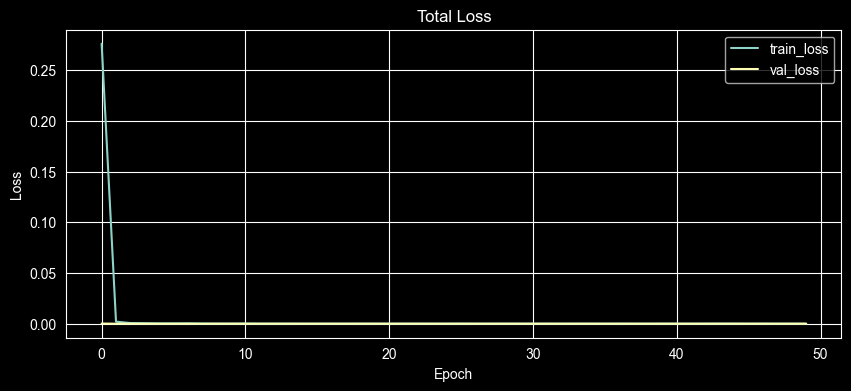

In [44]:
# ======================================
# 19. 학습 곡선 시각화 - 전체 손실
# ======================================

#figure 생성
plt.figure(figsize = (10,4))

# 학습 손실
plt.plot(history.history['loss'], label = 'train_loss')

# 검증 손실
plt.plot(history.history['val_loss'],label = 'val_loss')

plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

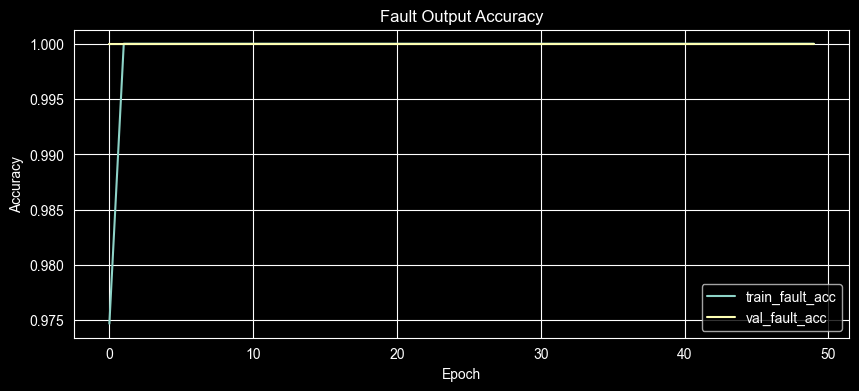

In [45]:
# ======================================
# 20 학습 곡선 시각화 - 고장 여부 분류기 (정상 vs 고장)
# ======================================

#figure 생성
plt.figure(figsize = (10,4))

# 고장 여부 학습 정확도
plt.plot(history.history['fault_output_accuracy'], label = 'train_fault_acc')

# 고장 여부 검증 정확도
plt.plot(history.history['val_fault_output_accuracy'],label = 'val_fault_acc')

plt.title("Fault Output Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


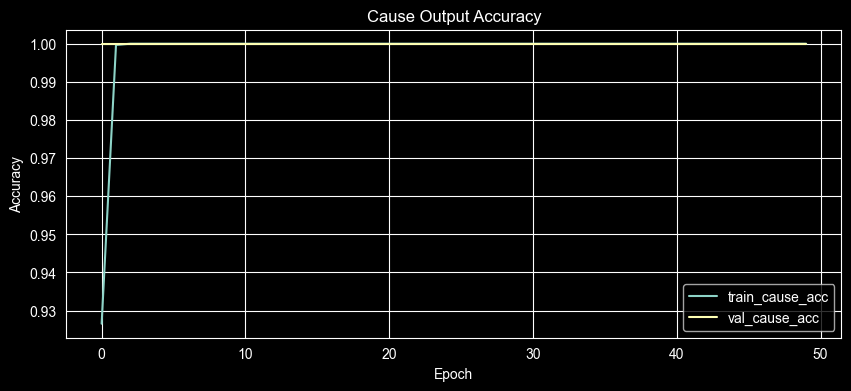

In [49]:
# ======================================
# 21 학습 곡선 시각화 - 원인 분류기 (멀티클래스)
# ======================================

# figure 생성
plt.figure(figsize = (10,4))

# 원인 분류 학습 정확도
plt.plot(history.history['cause_output_accuracy'], label = 'train_cause_acc')

# 원인 분류 검증 정확도
plt.plot(history.history['val_cause_output_accuracy'],label = 'val_cause_acc')

plt.title("Cause Output Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

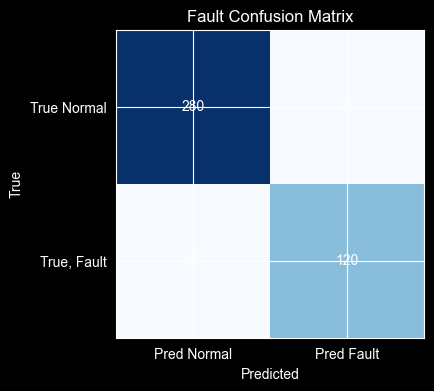

In [54]:
# ======================================
# 22 confusion matrix 시각화 - 고장 여부
# ======================================

plt.figure(figsize = (5,4))

# confusion matrix 이미지 표시
plt.imshow(fault_cm, cmap = "Blues")
plt.title("Fault Confusion Matrix")
plt.xticks([0,1], ["Pred Normal", "Pred Fault"])

# y축 눈금 설정
plt.yticks([0,1], ['True Normal', "True, Fault"])

# 셀 내부에 숫자 작성
for i in range(fault_cm.shape[0]):
    for j in range(fault_cm.shape[1]):
        plt.text(j,i, fault_cm[i,j],ha="center",va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

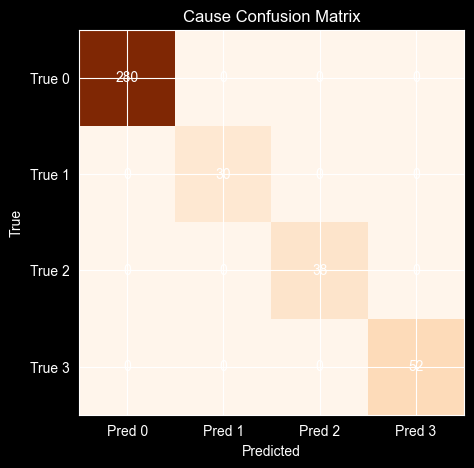

In [55]:
# ======================================
# 23 원인 분류
# ======================================
plt.figure(figsize = (6,5))

# confusion matrix 이미지 표시
plt.imshow(cause_cm, cmap = "Oranges")
plt.title("Cause Confusion Matrix")

# x 축 눈금 설정
plt.xticks(range(n_cause_classes), [f"Pred {i}" for i in range(n_cause_classes)])

# y축 눈금 설정
plt.yticks(range(n_cause_classes), [f"True {i}" for i in range(n_cause_classes)])

# 셀 내부에 숫자 작성
for i in range(cause_cm.shape[0]):
    for j in range(cause_cm.shape[1]):
        plt.text(j,i, cause_cm[i,j],ha="center",va="center")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


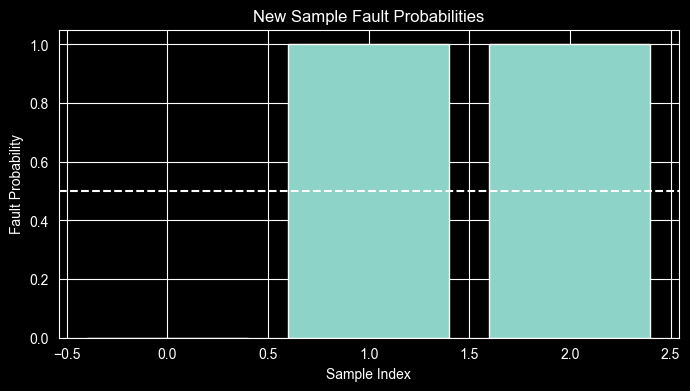

In [56]:
# ======================================
# 24 신규 데이터 예측 결과 시각화 - 고장 확률
# ======================================
plt.figure(figsize = (8,4))

# 신규 샘플 고장 확률 막대 그래프
plt.bar(range(len(new_fault_prob)), new_fault_prob.flatten())

# 기준선 0.5 포ㅛ시
plt.axhline(0.5, linestyle = "--")

plt.title("New Sample Fault Probabilities")
plt.xlabel('Sample Index')
plt.ylabel("Fault Probability")
plt.grid(True)
plt.show()

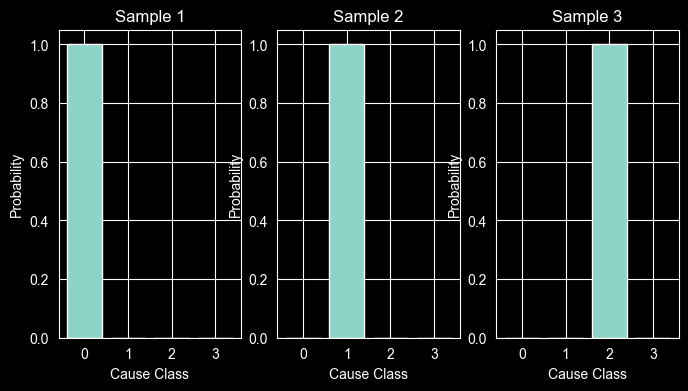

In [57]:
# ======================================
# 25 신규 데이터 예측 결과 시각화 - 원인 클래스 확률
# ======================================
plt.figure(figsize = (8,4))

# 신규 샘플 수만큼 반복
for i in range(len(new_cause_prob)):
    #1 행 N열 구조로 subplot 생성
    plt.subplot(1, len(new_cause_prob), i+1)

    # 해당 샘플의 원인 클래스 확률 막대그래프
    plt.bar(range(n_cause_classes), new_cause_prob[i])

    plt.title(f"Sample {i + 1}")
    plt.xlabel("Cause Class")
    plt.ylabel("Probability")

    # x축 눈금 설정
    plt.xticks(range(n_cause_classes))
    plt.grid(True)

plt.show()

# 이게 좋은 모델인지, 딥러닝 모델과 비교해서 교차검증 실시 필수

In [ ]:
# ======================================
# 26
# ======================================

